### **Used Car Price Prediction**: *Comparing Regression Models*  
**Introduction:**   
This project aims to predict the selling prices of used cars using a [dataset](https://www.kaggle.com/datasets/ahmedfakhar123/used-car-price-prediction-dataset/data?select=Used_Car_Prices.csv) obtained from Kaggle.  
The project explores the factors associated with used-car prices and compares the predictive performance of three regression models: Multiple Linear Regression, Decision Tree, and Random Forest, implemented using the scikit-learn library.  

The dataset contains a relatively small set of vehicle characteristics. Important determinants of used-car prices such as model, manufacturing year, engine size and transmission are unavailable. Therefore, the project should be viewed primarily as an exploration of how well prices can be predicted from limited vehicle information rather than as a production-ready valuation system.

## Step 1: Data Understanding & Cleaning

In [1]:
# Importing the necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error 

In [2]:
# import the data 
url = 'https://raw.githubusercontent.com/F-Nakabugo/used-car-price-prediction/refs/heads/main/data/Used_Car_Prices.csv'
df = pd.read_csv(url)

In [3]:
# Preview the first 8 rows of the dataset 
df.head(8)

,brand,km_driven,fuel,owner,selling_price
0,Maruti,145500,Diesel,First Owner,450000
1,Skoda,120000,Diesel,Second Owner,370000
2,Honda,140000,Petrol,Third Owner,158000
3,Hyundai,127000,Diesel,First Owner,225000
4,Maruti,120000,Petrol,First Owner,130000
5,Hyundai,45000,Petrol,First Owner,440000
6,Maruti,175000,LPG,First Owner,96000
7,Maruti,5000,Petrol,Second Owner,45000


In [4]:
# Check the number of rows and columns 
df.shape

(8128, 5)

In [5]:
# Inspect column data types and non-null counts 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   brand          8128 non-null   str  
 1   km_driven      8128 non-null   int64
 2   fuel           8128 non-null   str  
 3   owner          8128 non-null   str  
 4   selling_price  8128 non-null   int64
dtypes: int64(2), str(3)
memory usage: 505.0 KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
km_driven,8128.0,69819.510827,56550.554958,1.0,35000.0,60000.0,98000.0,2360457.0
selling_price,8128.0,638271.807702,806253.403508,29999.0,254999.0,450000.0,675000.0,10000000.0


In [7]:
# Checking for the number of missing values in each column 
df.isnull().sum()

brand            0
km_driven        0
fuel             0
owner            0
selling_price    0
dtype: int64

In [8]:
# Checking for duplicates 
print(df.duplicated().sum() )          

# further investigation into the duplicates 
duplicates = df[df.duplicated(keep=False)].sort_values(by=list(df.columns))
print(duplicates)

# Identify the car brands with the most identical records
duplicates['brand'].value_counts()

1678
      brand  km_driven    fuel        owner  selling_price
1977   Audi      22000  Diesel  First Owner        2825000
7324   Audi      22000  Diesel  First Owner        2825000
131    Audi      31800  Diesel  First Owner        3975000
1561   Audi      31800  Diesel  First Owner        3975000
1857   Audi      31800  Diesel  First Owner        3975000
...     ...        ...     ...          ...            ...
6693  Volvo      20000  Diesel  First Owner        3800000
6963  Volvo      20000  Diesel  First Owner        3800000
7862  Volvo      20000  Diesel  First Owner        3800000
145   Volvo      22000  Diesel  First Owner        3400000
3251  Volvo      22000  Diesel  First Owner        3400000

[2629 rows x 5 columns]


brand
Maruti           801
Hyundai          424
Mahindra         222
Tata             222
Toyota           189
Honda            159
BMW               89
Ford              88
Jaguar            68
Renault           64
Volvo             61
Skoda             43
Chevrolet         35
Lexus             34
Volkswagen        32
Datsun            19
Nissan            16
Mercedes-Benz     15
Jeep              14
Audi              10
Fiat               6
Mitsubishi         6
Force              4
Land               4
Isuzu              2
Kia                2
Name: count, dtype: int64

**FINDINGS**  
- The dataset contains 5 columns and 8,128 records, with each record representing a used car described by its brand, mileage, fuel type, ownership category, and selling price.  
- There are no missing values.  
- There are two numerical columns, km_driven and selling_price. The rest of the columns are categorical. We shall employ one-hot encoding on the categorical columns.  
- Among records belonging to the **duplicated groups**, Maruti is the most represented car brand with 801 records, while Kia is the least represented with 2 records.  
- Although 1,678 duplicate records were identified, they will be retained because, given the limited number and nature of the features, there is a high chance of identical records representing different physical cars rather than true duplicates.  

## Step 2: Exploratory Data Analysis 

This section explores the distribution of the target variable, **selling price**, and investigates how selected vehicle characteristics relate to it.  
It also examines the relationship between **mileage (`km_driven`)** and selling price, along with other patterns that may help explain variations in used-car prices.

In [9]:
# Define a function to visualize feature distributions 
def feature_distribution(dataset):
    col_list = dataset.columns

    fig, axes = plt.subplots(2,3, figsize=(15,8))
    axes = axes.flatten()

    for i, col in enumerate(col_list):

        if dataset[col].dtype == str:
            sns.countplot(data=dataset, x=col, ax=axes[i])
        else:
            sns.histplot(data=dataset, x=col, ax=axes[i])

        axes[i].set_title(f'Distribution of {col}')
        axes[i].tick_params(axis='x', rotation=90)
    # removing unused subplot 
    for i in range(len(col_list), len(axes)):
        fig.delaxes(axes[i])
        
    plt.tight_layout()
    plt.show()

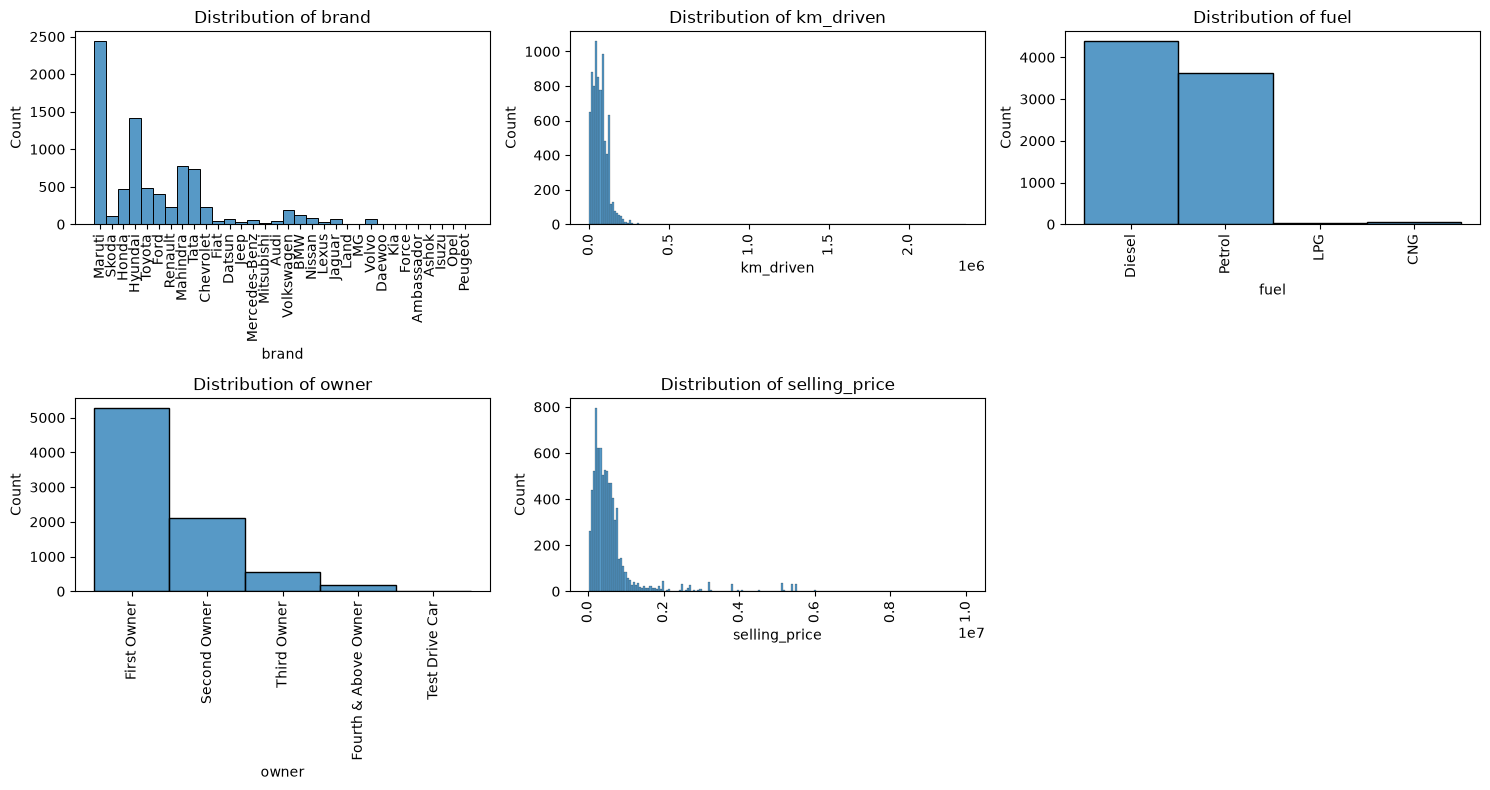

In [10]:
feature_distribution(dataset=df)

**Observations from feature distributions:**  

1. **Brand**: Maruti is the most represented car brand in the dataset, followed by Hyundai, Mahindra, and Tata.
2. **Kilometres driven**: Most cars have a mileage below 300,000 km. The distribution is strongly right-skewed, with a small number of cars having extremely high km_driven values.
3. **Ownership**: More than 5,000 cars are first-owner vehicles. The number of cars generally decreases as the number of previous owners increases, with significantly fewer cars having three or more owners.
4. **Fuel type**: Diesel and petrol are the dominant fuel types in the dataset, while relatively few cars use LPG or CNG.
5. **Selling price**: Most cars have a selling price below 1,000,000. The distribution is right-skewed, indicating that a relatively small number of cars have substantially higher selling prices.

In [11]:
# Exploring the relationship with the target 

def compare_target(dataset, target): 

    """A function that takes a dataframe and target variable as 
    inputs to visualize the relationship between the target and 
    each of the features using a scatter plot for numerical features
    and boxplot for categorical features."""

    col_list = dataset.columns 

    for col in col_list:
        if col == target:
            continue
        plt.figure(figsize=(8,3))

        if dataset[col].dtype == 'int64':
            sns.scatterplot(data=dataset, 
                            x=col,
                            y=target)
        else:
            sns.boxplot(data=dataset, 
                        x=col,
                        y=target)
        plt.xticks(rotation=90)              
        plt.show()


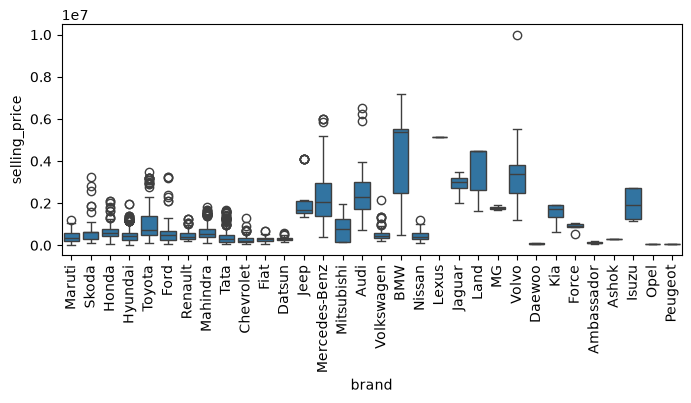

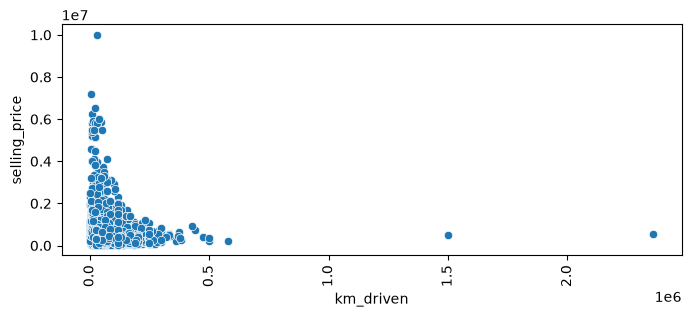

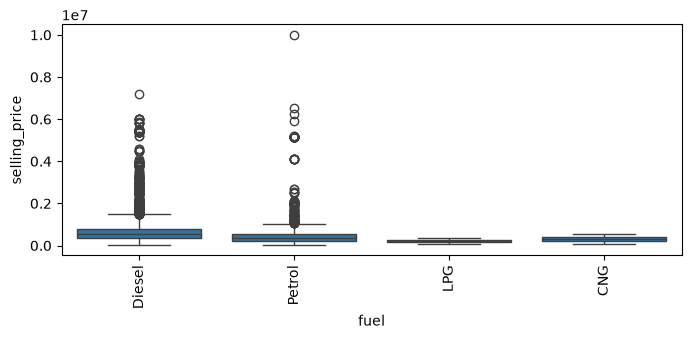

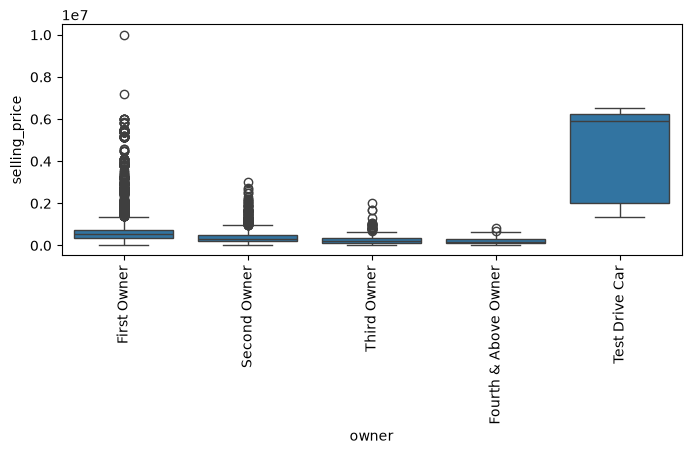

In [12]:
compare_target(df, 'selling_price')

FINDINGS 

**Brand**
Selling prices vary across brands. BMW, Land Rover, and Lexus generally have higher prices, while Maruti, Skoda, and Hyundai mostly fall below 2,000,000.

**km_driven**
Vehicles with lower mileage generally have higher selling prices. Most vehicles have mileage below 500,000 km, while the few vehicles above 1,500,000 km have relatively low selling prices.

**Fuel**
Diesel cars generally have higher selling prices than other fuel types, while LPG vehicles have the lowest and least variable prices. Diesel and Petrol also contain several high-price outliers.

**Owner**
Test Drive cars have substantially higher selling prices than the other ownership categories. Their typical price is around 6,000,000, compared with about 600,000 for First Owner cars, although this comparison should be interpreted cautiously if the Test Drive category contains very few vehicles.

## Step 3: Data Preprocessing

In [13]:
df = df.copy()
df

,brand,km_driven,fuel,owner,selling_price
0,Maruti,145500,Diesel,First Owner,450000
1,Skoda,120000,Diesel,Second Owner,370000
2,Honda,140000,Petrol,Third Owner,158000
3,Hyundai,127000,Diesel,First Owner,225000
4,Maruti,120000,Petrol,First Owner,130000
...,...,...,...,...,...
8123,Hyundai,110000,Petrol,First Owner,320000
8124,Hyundai,119000,Diesel,Fourth & Above Owner,135000
8125,Maruti,120000,Diesel,First Owner,382000
8126,Tata,25000,Diesel,First Owner,290000


In this section, **One-hot encoding** is used to convert categorical variables into numerical format by creating separate binary columns for each category, allowing machine learning models to process these features without implying an ordinal relationship between them.

In [14]:
# defining the one-hot encoding function 
def encoding(dataset): 
    cat_col = dataset.select_dtypes(exclude='number').columns

    for col in cat_col:
        encoded_col = pd.get_dummies(dataset[col], prefix=col, dtype=int)

        # add encoded columns 
        dataset = pd.concat([dataset, encoded_col], axis=1)

        # remove original categorical columns
        dataset= dataset.drop(columns=[col])

    return dataset


In [15]:
encoded_df = encoding(df)

In [16]:
pd.set_option('display.max_columns', None)
encoded_df.head()

,km_driven,selling_price,brand_Ambassador,brand_Ashok,brand_Audi,brand_BMW,brand_Chevrolet,brand_Daewoo,brand_Datsun,brand_Fiat,brand_Force,brand_Ford,brand_Honda,brand_Hyundai,brand_Isuzu,brand_Jaguar,brand_Jeep,brand_Kia,brand_Land,brand_Lexus,brand_MG,brand_Mahindra,brand_Maruti,brand_Mercedes-Benz,brand_Mitsubishi,brand_Nissan,brand_Opel,brand_Peugeot,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo,fuel_CNG,fuel_Diesel,fuel_LPG,fuel_Petrol,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,145500,450000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0
1,120000,370000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0
2,140000,158000,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1
3,127000,225000,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0
4,120000,130000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0


In the next stage, the predictor features are separated from the target variable, and the dataset is split into training and testing sets.  

The km_driven feature is standardized because it has a much larger numerical scale. While scaling is not required for the tree-based models used in this project, it provides consistent preprocessing and can be useful for models that are sensitive to feature magnitude.  
    
The scaler is fitted only on the training data and then used to transform both the training and test sets. This helps prevent information from the test set from influencing the training process.

In [17]:
# separate the target and features 
X = encoded_df.drop(columns=['selling_price'])
y = encoded_df['selling_price']

# splitting data 
X_train, X_test, y_train, y_test = train_test_split(
                                    X,
                                    y,
                                    test_size=0.2,
                                    random_state=42
)

# create scaler 
scaler = StandardScaler()

# Learning scaling from training data 
X_train['km_driven'] = scaler.fit_transform(X_train[['km_driven']])

# Apply the fitted scaler to the test data
X_test['km_driven'] = scaler.transform(X_test[['km_driven']])

## Step 4: Model Building 

### Multiple Linear Regression  
We begin by building a Multiple Linear Regression (MLR) model to establish a simple and interpretable baseline for predicting used-car prices.  
The model estimates selling price based on the combined relationship between the selected vehicle features and the target variable.

In [18]:
# MODEL 1: Building an MLR model 

linear_model = LinearRegression()               # instantiating model 

linear_model.fit(X_train, y_train)              # training the model

# Generate predictions
y_predictions = linear_model.predict(X_test)

In [19]:
# evaluating the model performance 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# assess model accuracy 
r_score = r2_score(y_test, y_predictions)
MAE = mean_absolute_error(y_test, y_predictions)
MSE = mean_squared_error(y_test, y_predictions)
RMSE = MSE**0.5         # gets the square root of MSE, option: Numpy

print('r2_score:', r_score, '\nMAE:', MAE, '\nRMSE:', RMSE) 

r2_score: 0.7778397792248126 
MAE: 216466.22623905187 
RMSE: 381605.25152964244


> **Remarks from MLR model evaluation:**   
An *R² score of 0.78* indicates that the model explains approximately 78% of the variation in used car selling prices, while the remaining 22% is not explained by the model.  
An MAE value of about 216,466 implies that on average, the predicted selling price differs from the actual price by about ₹216,466.   
An RMSE of approximately ₹381,605 indicates that prediction errors can be substantial, with larger errors receiving greater weight in this metric.

### Decision Tree Regressor
Next, a Decision Tree Regressor is developed to capture potential non-linear relationships between the vehicle features and selling price and to assess whether it improves upon the linear regression model.  
We will use cross-validation to find the `max_depth` that gives the best model performance.  
The cross-validation results below show that `max_depth = 15` gives the highest value of the R² score. So, we shall use this in training our actual model. 

In [20]:
# Testing out different max_depth values 
for depth in [5, 10, 15, 20, 25]:
    trial_model = DecisionTreeRegressor(max_depth=depth,
                                        random_state=42)
    scores = cross_val_score(
        trial_model,
        X_train,
        y_train, 
        cv=5, 
        scoring='r2'
    )
    print(depth, round(scores.mean(), 3))

5 0.679
10 0.792
15 0.823
20 0.821
25 0.817


In [21]:
# MODEL 2: Building a Decision Tree

# instantiate the tree model 
dec_tree = DecisionTreeRegressor(max_depth=15, random_state=30)

# training the model 
dec_tree.fit(X_train, y_train)

# making predictions using the Decision Tree 
y_pred = dec_tree.predict(X_test)

# Evaluating model performance 
dec_r2_score = r2_score(y_test, y_pred)
dec_MAE = mean_absolute_error(y_test, y_pred)
dec_MSE = mean_squared_error(y_test, y_pred)    
dec_RMSE = round(dec_MSE**0.5, 2)

# Report metrics  
print('Decision tree r2 score:', round(dec_r2_score, 3))
print('Decision tree MAE:', round(dec_MAE, 2))
print('Decision tree RMSE:', dec_RMSE)


Decision tree r2 score: 0.783
Decision tree MAE: 184173.59
Decision tree RMSE: 377504.12


> **Remarks from Decision Tree model evaluation:**  
The decision tree model shows a slight improvement over the Multiple Linear Regression model. `Its r2 score increased from 77.8% to 78.3%`, meaning that the model explains approximately 78.3% of the variation in used car selling prices.  
There is also a noticeable decrease in both the MAE and RMSE. The MAE dropped from ₹216,466 to ₹184,173, while the RMSE decreased from ₹381,605 to ₹377,504. This indicates an overall improvement in prediction errors.  
However, about 21.7% of the variation in selling prices is still not explained by the model. Next, we will train a `Random Forest` model and assess whether it can improve the predictive performance further. 

### Random Forest Regressor     
Finally, a Random Forest Regressor is developed to improve predictive performance by combining multiple decision trees, potentially providing more stable and accurate predictions than a single decision tree.

In [22]:
# instantiate the random forest model 
RF = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=34)

# training the model 
RF.fit(X_train, y_train)

# Getting predictions 
RF_predictions = RF.predict(X_test)

In [23]:
# evaluating model performance 
RF_r2_score = r2_score(y_test, RF_predictions)
RF_MAE = mean_absolute_error(y_test, RF_predictions)
RF_MSE = mean_squared_error(y_test, RF_predictions)  
RF_RMSE = round(RF_MSE**0.5, 2)

# Report RMSE 
print('Random forest r2 score:', round(RF_r2_score, 3))
print('Random forest MAE:', round(RF_MAE, 2))
print('Random forest RMSE:', RF_RMSE)

Random forest r2 score: 0.824
Random forest MAE: 177752.36
Random forest RMSE: 340132.37


> **Remarks from the Random Forest evaluation:**  
The **Random Forest model shows an improvement in predictive performance**, with the R² score increasing from 78.3% for the Decision Tree model to approximately 82.4%.  
The MAE and RMSE have also decreased further to ₹177,752 and ₹340,132, respectively, indicating lower prediction errors.  
Overall, the Random Forest model outperforms both the Multiple Linear Regression and Decision Tree models, as demonstrated by its higher R² score and lower MAE and RMSE values.

### Model Comparison

In [24]:
model_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'R²' : [r_score, dec_r2_score, RF_r2_score],
    'MAE' : [MAE, dec_MAE, RF_MAE],
    'RMSE' :[RMSE, dec_RMSE, RF_RMSE]
})

model_results.style.format({
    'R²': '{:.3f}',
    'MAE': '₹{:,.0f}',
    'RMSE': '₹{:,.0f}'
})

,Model,R²,MAE,RMSE
0,Linear Regression,0.778,"₹216,466","₹381,605"
1,Decision Tree,0.783,"₹184,174","₹377,504"
2,Random Forest,0.824,"₹177,752","₹340,132"


### Prediction Error Analysis

In [25]:
prediction_errors = pd.DataFrame({
    'Brand': df.loc[y_test.index, 'brand'],
    'Actual price': y_test,
    'Predicted price': RF_predictions,
    'Absolute error': (RF_predictions-y_test).abs()
})

prediction_errors.sort_values(by='Absolute error', 
                              ascending=False).head(10).style.format({
    'Actual price': '₹{:,.0f}',
    'Predicted price': '₹{:,.0f}',
    'Absolute error': '₹{:,.0f}'
})

,Brand,Actual price,Predicted price,Absolute error
4299,Mercedes-Benz,"₹650,000","₹5,298,590","₹4,648,590"
3107,Mercedes-Benz,"₹400,000","₹3,800,090","₹3,400,090"
4766,BMW,"₹6,000,000","₹2,851,233","₹3,148,767"
8058,Audi,"₹1,689,999","₹4,437,835","₹2,747,836"
2840,Volvo,"₹1,950,000","₹4,508,000","₹2,558,000"
2932,Mercedes-Benz,"₹1,250,000","₹3,800,090","₹2,550,090"
681,Mercedes-Benz,"₹3,000,000","₹5,360,090","₹2,360,090"
4952,Audi,"₹6,523,000","₹4,358,018","₹2,164,982"
1979,BMW,"₹3,350,000","₹5,437,000","₹2,087,000"
7326,BMW,"₹3,350,000","₹5,437,000","₹2,087,000"


> The largest prediction errors appear to be concentrated among luxury car brands such as Mercedes-Benz, BMW, Audi, and Volvo. This suggests that the model may have more difficulty predicting prices for these vehicles.  
Further investigation would be needed to determine the cause of these errors, including whether the limited vehicle features and duplicate observations in the dataset contribute to this pattern. 

## Conclusion and Limitations

The model with the best overall performance was the Random Forest with an R² of 0.82, MAE of ₹177,752, and RMSE of ₹340,132. 

From the exploratory analysis, Maruti was the most represented brand in the dataset, followed by Hyundai, Mahindra, and Tata.. Most vehicles were first-owner cars, and diesel was the most common fuel type followed by petrol.   
Selling prices also varied across brand, mileage, fuel type, and owner category. BMW and Land Rover had some of the highest selling prices, while brands such as Maruti, Skoda, and Hyundai had lower prices in this dataset.    

Although the Random Forest explained a substantial proportion of the variation in selling prices, the prediction errors are still relatively high. This limits how confidently the model could be used for real-world vehicle pricing. 

> Error analysis also showed that some of the largest prediction errors occurred among luxury brands such as Mercedes-Benz, BMW, Audi, and Volvo. Further investigation would be required to investigate this pattern. 
   
The model could potentially be improved by using a richer dataset containing additional vehicle characteristics such as:
- Age/year of manufacture 
- Engine size 
- Transmission
- Accident/damage history 
